In [35]:
!pip install wfdb -q

In [36]:
# =====================================================
# RECORD LIST (15 VALID PTB RECORDS)
# =====================================================

records=[

"patient001/s0010_re",
"patient001/s0014lre",
"patient001/s0016lre",

"patient002/s0015lre",

"patient003/s0017lre",

"patient004/s0020are",
"patient004/s0020bre",

"patient005/s0021are",
"patient005/s0021bre",
"patient005/s0025lre",
"patient005/s0031lre",
"patient005/s0101lre",

"patient006/s0022lre",
"patient006/s0027lre",
"patient006/s0064lre"

]


assert len(records)>0


assert len(records)==len(

set(records)

),"Duplicate records found"



print(

"Total Records:",

len(records)

)


print(

"\nSelected Records:\n"

)


for r in records:

    print(r)

Total Records: 15

Selected Records:

patient001/s0010_re
patient001/s0014lre
patient001/s0016lre
patient002/s0015lre
patient003/s0017lre
patient004/s0020are
patient004/s0020bre
patient005/s0021are
patient005/s0021bre
patient005/s0025lre
patient005/s0031lre
patient005/s0101lre
patient006/s0022lre
patient006/s0027lre
patient006/s0064lre


In [37]:
# =====================================================
# DOWNLOAD PTB RECORDS (LIVE PROGRESS)
# =====================================================

import os
import urllib.request
import sys


save_dir="/kaggle/working/ptb_subset"

os.makedirs(

    save_dir,

    exist_ok=True

)


base_url=(

"https://physionet.org/files/ptbdb/1.0.0/"

)



for i,rec in enumerate(

    records,

    start=1

):


    print(

f"\n[{i}/{len(records)}] Downloading:",

rec

    )

    sys.stdout.flush()



    for ext in [

        ".hea",

        ".dat",

        ".xyz"

    ]:



        save_path=os.path.join(

            save_dir,

            rec+ext

        )


        os.makedirs(

            os.path.dirname(

                save_path

            ),

            exist_ok=True

        )



        print(

f"     Starting {ext}..."

        )

        sys.stdout.flush()



        if os.path.exists(

            save_path

        ):


            print(

f"     EXISTS: {save_path}"

            )

            sys.stdout.flush()

            continue



        try:


            url=(

base_url+

rec+

ext

            )



            urllib.request.urlretrieve(

                url,

                save_path

            )



            print(

f"     Saved: {save_path}"

            )

            sys.stdout.flush()



        except Exception as e:


            print(

f"     ERROR:",

e

            )

            sys.stdout.flush()



print(

"\n================================"

)

print(

"DOWNLOAD COMPLETE"

)

print(

"================================"
)


[1/15] Downloading: patient001/s0010_re
     Starting .hea...
     EXISTS: /kaggle/working/ptb_subset/patient001/s0010_re.hea
     Starting .dat...
     EXISTS: /kaggle/working/ptb_subset/patient001/s0010_re.dat
     Starting .xyz...
     EXISTS: /kaggle/working/ptb_subset/patient001/s0010_re.xyz

[2/15] Downloading: patient001/s0014lre
     Starting .hea...
     EXISTS: /kaggle/working/ptb_subset/patient001/s0014lre.hea
     Starting .dat...
     EXISTS: /kaggle/working/ptb_subset/patient001/s0014lre.dat
     Starting .xyz...
     EXISTS: /kaggle/working/ptb_subset/patient001/s0014lre.xyz

[3/15] Downloading: patient001/s0016lre
     Starting .hea...
     EXISTS: /kaggle/working/ptb_subset/patient001/s0016lre.hea
     Starting .dat...
     EXISTS: /kaggle/working/ptb_subset/patient001/s0016lre.dat
     Starting .xyz...
     EXISTS: /kaggle/working/ptb_subset/patient001/s0016lre.xyz

[4/15] Downloading: patient002/s0015lre
     Starting .hea...
     EXISTS: /kaggle/working/ptb_subset/

In [38]:
# =====================================================
# VERIFY DOWNLOADED RECORDS
# =====================================================

import wfdb


verified=[]

failed=[]



for i,rec in enumerate(

    records,

    start=1

):


    try:


        path=(

"/kaggle/working/ptb_subset/"

+

rec

        )


        temp=wfdb.rdrecord(

            path

        )


        print(

f"[{i}/{len(records)}] ✓",

rec,

temp.p_signal.shape

        )


        verified.append(

            rec

        )



    except Exception as e:


        print(

f"[{i}/{len(records)}] ✗",

rec,

e

        )


        failed.append(

            rec

        )




print(

"\n======================"

)


print(

"Verified:",

len(

verified

)

)


print(

"Failed:",

len(

failed

)

)



if len(

failed

)>0:


    print(

"\nFailed records:\n"

    )


    for f in failed:


        print(f)



print(

"======================"

)



# DO NOT overwrite records


verified_records=verified

[1/15] ✓ patient001/s0010_re (38400, 15)
[2/15] ✓ patient001/s0014lre (115200, 15)
[3/15] ✓ patient001/s0016lre (115200, 15)
[4/15] ✓ patient002/s0015lre (115200, 15)
[5/15] ✓ patient003/s0017lre (115200, 15)
[6/15] ✓ patient004/s0020are (115200, 15)
[7/15] ✓ patient004/s0020bre (115200, 15)
[8/15] ✓ patient005/s0021are (115174, 15)
[9/15] ✓ patient005/s0021bre (115174, 15)
[10/15] ✓ patient005/s0025lre (115200, 15)
[11/15] ✓ patient005/s0031lre (115200, 15)
[12/15] ✓ patient005/s0101lre (115200, 15)
[13/15] ✓ patient006/s0022lre (115174, 15)
[14/15] ✓ patient006/s0027lre (115200, 15)
[15/15] ✓ patient006/s0064lre (115200, 15)

Verified: 15
Failed: 0


In [39]:
# =====================================================
# LOAD VERIFIED PTB RECORDS
# =====================================================

dataset=[]

failed=[]



for i,rec in enumerate(

    verified_records,

    start=1

):


    try:


        path=(

"/kaggle/working/ptb_subset/"

+

rec

        )


        print(

f"[{i}/{len(verified_records)}] Loading:",

rec,

flush=True

        )



        r=wfdb.rdrecord(

            path

        )


        names=r.sig_name


        sig=r.p_signal



        required=[

            "vx",

            "vy",

            "vz"

        ]


        if not all(

            x in names

            for x in required

        ):


            raise Exception(

                "Missing VCG leads"

            )




        dataset.append({


            "name":

            rec.split(

                "/"

            )[-1],


            "x":

            sig[:,

            names.index(

                "vx"

            )],


            "y":

            sig[:,

            names.index(

                "vy"

            )],


            "z":

            sig[:,

            names.index(

                "vz"

            )]

        })



        print(

"     Shape:",

sig.shape

        )



    except Exception as e:


        print(

f"     ERROR:",

e

        )


        failed.append(

            rec

        )




print(

"\n======================"

)


print(

"Loaded:",

len(

dataset

)

)


print(

"Failed:",

len(

failed

)

)


print(

"======================"
)

[1/15] Loading: patient001/s0010_re
     Shape: (38400, 15)
[2/15] Loading: patient001/s0014lre
     Shape: (115200, 15)
[3/15] Loading: patient001/s0016lre
     Shape: (115200, 15)
[4/15] Loading: patient002/s0015lre
     Shape: (115200, 15)
[5/15] Loading: patient003/s0017lre
     Shape: (115200, 15)
[6/15] Loading: patient004/s0020are
     Shape: (115200, 15)
[7/15] Loading: patient004/s0020bre
     Shape: (115200, 15)
[8/15] Loading: patient005/s0021are
     Shape: (115174, 15)
[9/15] Loading: patient005/s0021bre
     Shape: (115174, 15)
[10/15] Loading: patient005/s0025lre
     Shape: (115200, 15)
[11/15] Loading: patient005/s0031lre
     Shape: (115200, 15)
[12/15] Loading: patient005/s0101lre
     Shape: (115200, 15)
[13/15] Loading: patient006/s0022lre
     Shape: (115174, 15)
[14/15] Loading: patient006/s0027lre
     Shape: (115200, 15)
[15/15] Loading: patient006/s0064lre
     Shape: (115200, 15)

Loaded: 15
Failed: 0


In [40]:
# =====================================================
# IMPORTS
# =====================================================

import os
import sys
import time
import shutil
import urllib.request


import wfdb

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt


from scipy.signal import (

    find_peaks

)


Record: s0010_re
Signal Length: 38400


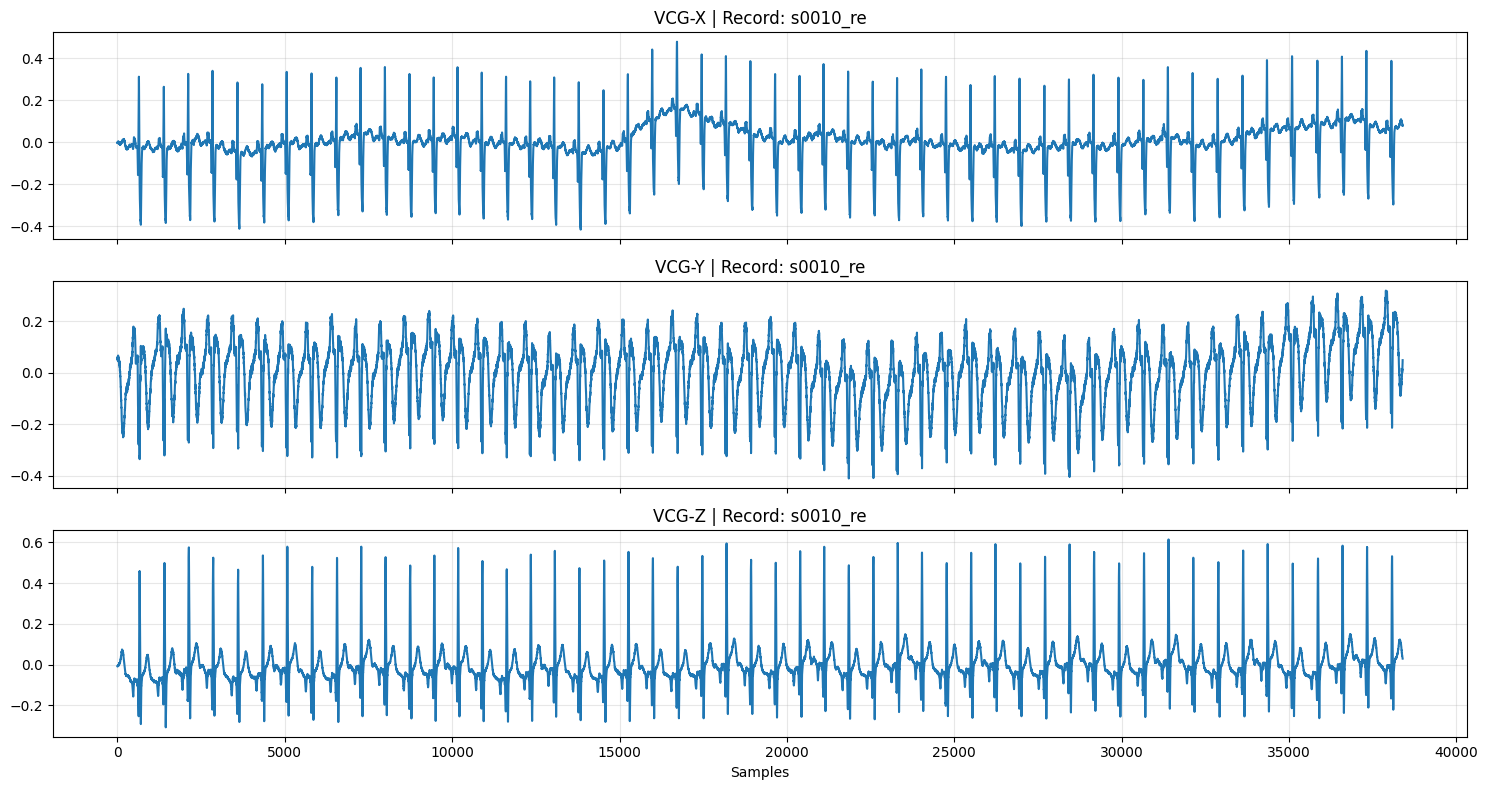

In [41]:
# =====================================================
# RAW VCG SIGNAL VISUALIZATION
# =====================================================

d=dataset[0]


print(

"\nRecord:",

d["name"]

)


print(

"Signal Length:",

len(

d["x"]

)

)




fig,ax=plt.subplots(

3,

1,

figsize=(15,8),

sharex=True

)



signals=[

("x","VCG-X"),

("y","VCG-Y"),

("z","VCG-Z")

]



for i,(lead,title) in enumerate(

signals

):


    ax[i].plot(

        d[lead]

    )


    ax[i].set_title(

f"{title} | Record: {d['name']}"

    )


    ax[i].grid(

        True,

        alpha=0.3

    )



plt.xlabel(

"Samples"

)


plt.tight_layout()

plt.show()

Record: s0010_re
Detected TRUE R peaks: 52


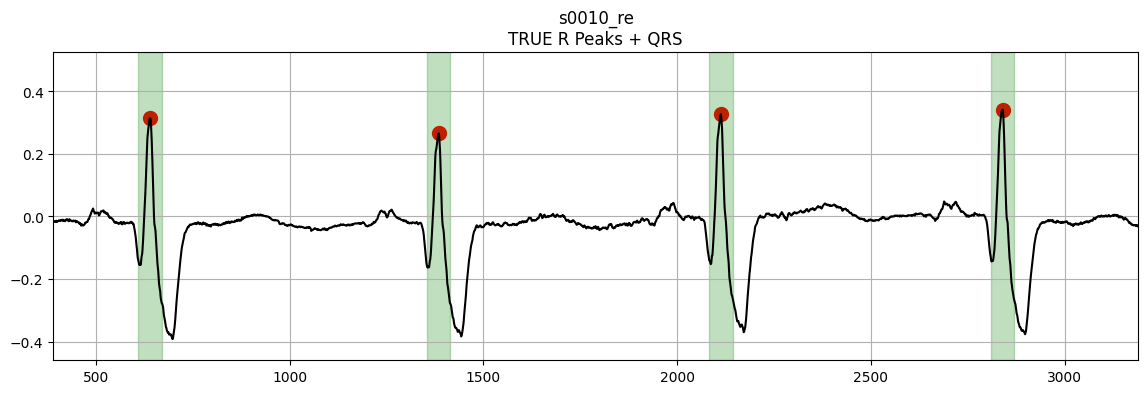

In [42]:
# ============================================
# STRICT R PEAK DETECTION 
# ============================================

import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks


record=dataset[0]

sig=record["x"]      # ONLY X LEAD

name=record["name"]



r_peaks,_=find_peaks(

    sig,

    distance=600,

    prominence=1.5*np.std(sig),

    height=np.mean(sig)+0.5*np.std(sig)

)



print(

"Record:",

name

)


print(

"Detected TRUE R peaks:",

len(r_peaks)

)



beats=min(

3,

len(r_peaks)-1

)



start=max(

0,

r_peaks[0]-250

)



end=min(

len(sig),

r_peaks[beats]+350

)



plt.figure(

figsize=(14,4)

)



plt.plot(

sig,

color='black'

)



for rp in r_peaks:


    if start<=rp<=end:


        plt.scatter(

            rp,

            sig[rp],

            color='red',

            s=100

        )



        plt.axvspan(

            rp-30,

            rp+30,

            alpha=.25,

            color='green'

        )



plt.xlim(

start,

end

)



plt.title(

f"{name}\nTRUE R Peaks + QRS"

)



plt.grid()

plt.show()

In [43]:
# =====================================================
# EXTRACT + ALIGN HEARTBEATS
# =====================================================


aligned_dataset=[]


WINDOW_BEFORE=80
WINDOW_AFTER=120



for i,d in enumerate(

    dataset,

    start=1

):


    print(

f"\n[{i}/{len(dataset)}] Processing:",

d["name"]

    )



    peaks=(

        d["r_peaks"]

        if "r_peaks" in d

        else find_peaks(

            d["x"],

            distance=200,

            prominence=0.3

        )[0]

    )



    beats_x=[]
    beats_y=[]
    beats_z=[]



    for p in peaks:



        start=p-WINDOW_BEFORE
        end=p+WINDOW_AFTER



        if (

            start>=0

            and

            end<len(

                d["x"]

            )

        ):



            bx=d["x"][start:end]
            by=d["y"][start:end]
            bz=d["z"][start:end]



            # ==========================
            # NORMALIZE
            # ==========================


            bx=(

bx-np.mean(

bx

)

)/(

np.std(

bx

)+1e-8

)


            by=(

by-np.mean(

by

)

)/(

np.std(

by

)+1e-8

)


            bz=(

bz-np.mean(

bz

)

)/(

np.std(

bz

)+1e-8

)



            beats_x.append(

                bx

            )

            beats_y.append(

                by

            )

            beats_z.append(

                bz

            )



    if len(

        beats_x

    )==0:


        print(

"No valid beats"

        )


        continue




    beats_x=np.array(

        beats_x

    )


    beats_y=np.array(

        beats_y

    )


    beats_z=np.array(

        beats_z

    )



    aligned_dataset.append({


        "name":

        d["name"],


        "Mx":

        beats_x,


        "My":

        beats_y,


        "Mz":

        beats_z,


        "r_peaks":

        peaks

    })




    print(

"Beats:",

len(

beats_x

)

    )


    print(

"Mx:",

beats_x.shape

    )



print(

"\n======================"

)


print(

"Aligned records:",

len(

aligned_dataset

)

)


print(

"======================"
)


[1/15] Processing: s0010_re
Beats: 52
Mx: (52, 200)

[2/15] Processing: s0014lre
Beats: 200
Mx: (200, 200)

[3/15] Processing: s0016lre
Beats: 290
Mx: (290, 200)

[4/15] Processing: s0015lre
Beats: 151
Mx: (151, 200)

[5/15] Processing: s0017lre
Beats: 139
Mx: (139, 200)

[6/15] Processing: s0020are
Beats: 158
Mx: (158, 200)

[7/15] Processing: s0020bre
Beats: 155
Mx: (155, 200)

[8/15] Processing: s0021are
Beats: 184
Mx: (184, 200)

[9/15] Processing: s0021bre
Beats: 183
Mx: (183, 200)

[10/15] Processing: s0025lre
Beats: 197
Mx: (197, 200)

[11/15] Processing: s0031lre
Beats: 176
Mx: (176, 200)

[12/15] Processing: s0101lre
Beats: 125
Mx: (125, 200)

[13/15] Processing: s0022lre
Beats: 176
Mx: (176, 200)

[14/15] Processing: s0027lre
Beats: 155
Mx: (155, 200)

[15/15] Processing: s0064lre
Beats: 149
Mx: (149, 200)

Aligned records: 15


Record: s0010_re
Mx: (52, 200)
My: (52, 200)
Mz: (52, 200)


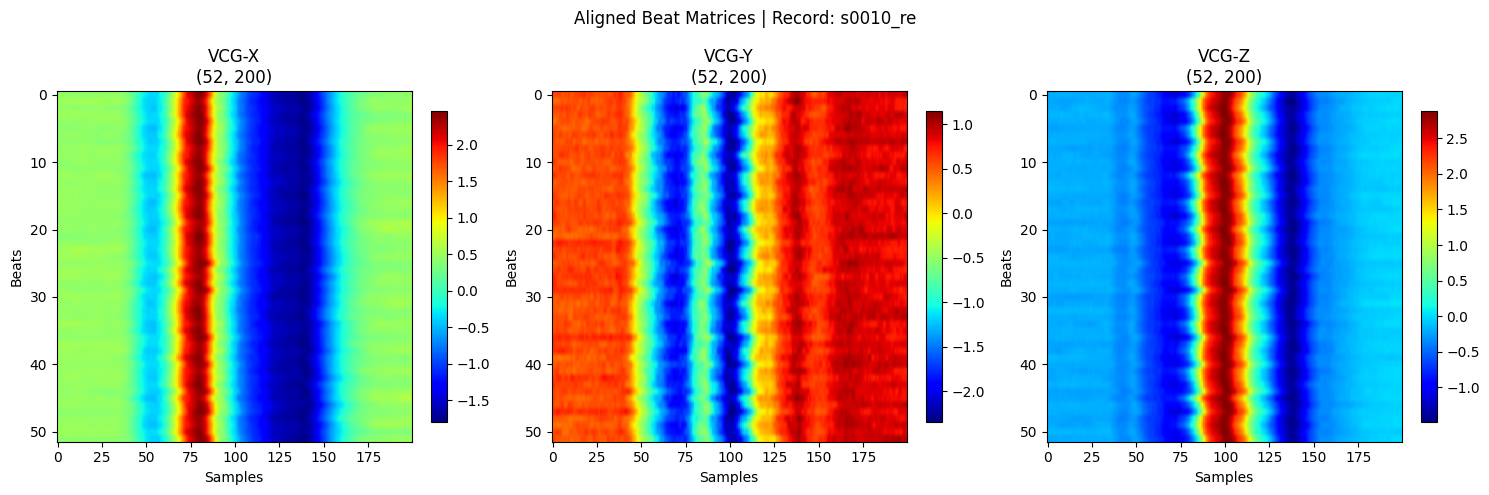

In [44]:
# =====================================================
# VISUALIZE ALIGNED BEAT MATRICES
# =====================================================

d=aligned_dataset[0]


print(

"Record:",

d["name"]

)


print(

"Mx:",

d["Mx"].shape

)


print(

"My:",

d["My"].shape

)


print(

"Mz:",

d["Mz"].shape

)



fig,ax=plt.subplots(

1,

3,

figsize=(15,5)

)



matrices=[

("Mx","VCG-X"),

("My","VCG-Y"),

("Mz","VCG-Z")

]



for i,(mat,title) in enumerate(

matrices

):


    im=ax[i].imshow(

        d[mat],

        aspect='auto',

        cmap='jet'

    )


    ax[i].set_title(

f"{title}\n{d[mat].shape}"

    )


    ax[i].set_xlabel(

"Samples"

    )


    ax[i].set_ylabel(

"Beats"

    )


    plt.colorbar(

        im,

        ax=ax[i],

        fraction=0.04

    )



plt.suptitle(

f"Aligned Beat Matrices | Record: {d['name']}"

)


plt.tight_layout()

plt.show()

Record: s0010_re

Lead X
Rank95: 1
Rank99: 1
Rank99.9: 3

Lead Y
Rank95: 1
Rank99: 1
Rank99.9: 13

Lead Z
Rank95: 1
Rank99: 1
Rank99.9: 3


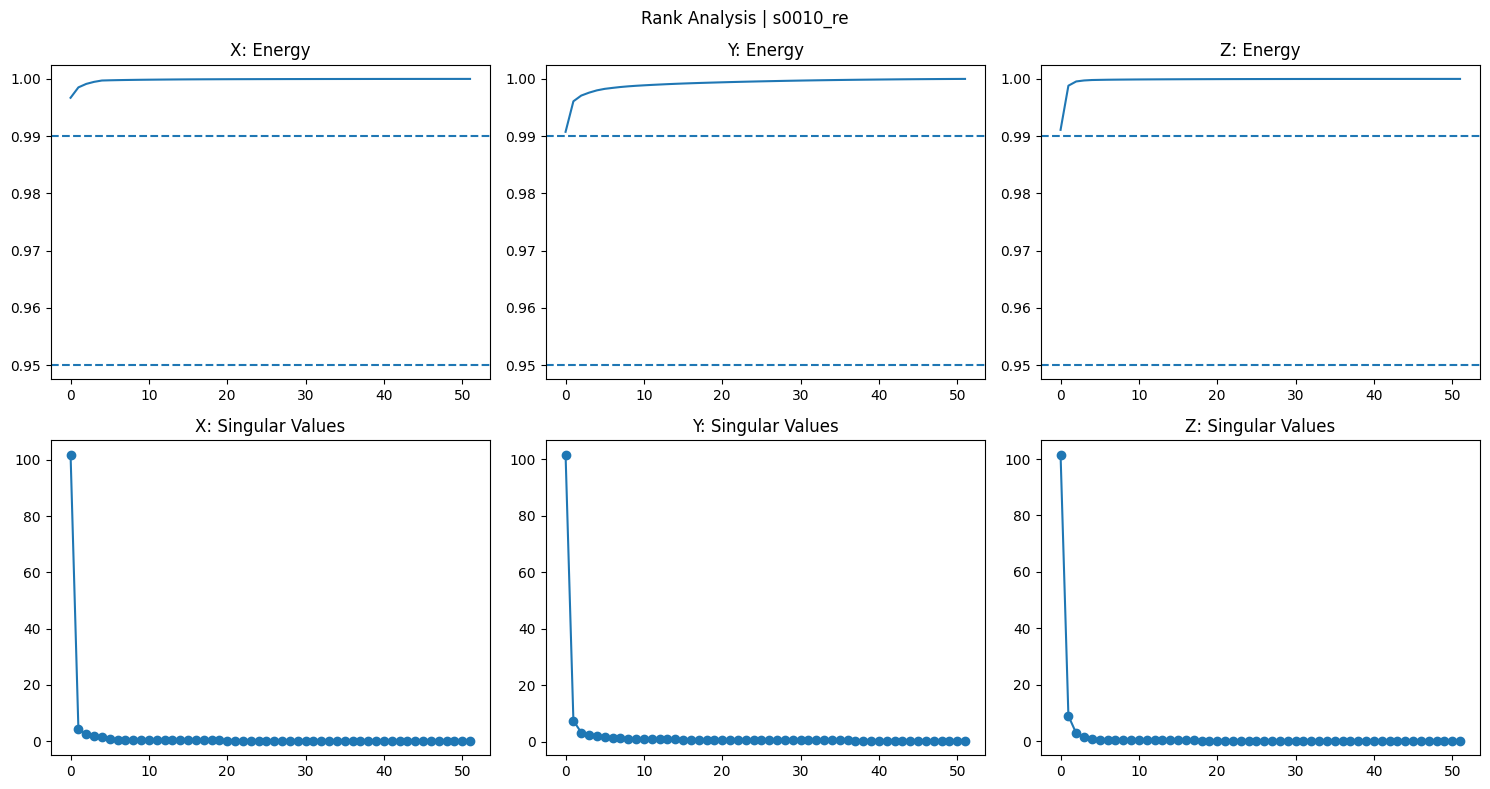

In [45]:
# =====================================================
# EFFECTIVE RANK + SINGULAR VALUE ANALYSIS
# =====================================================

d=aligned_dataset[0]


print(

"Record:",

d["name"]

)



fig,ax=plt.subplots(

2,

3,

figsize=(15,8)

)



for i,(lead,M) in enumerate(

zip(

["X","Y","Z"],

[d["Mx"],d["My"],d["Mz"]]

)

):



    U,S,VT=np.linalg.svd(

        M,

        full_matrices=False

    )



    energy=np.cumsum(

        S**2

    )


    energy/=energy[-1]



    rank95=np.argmax(

        energy>=0.95

    )+1


    rank99=np.argmax(

        energy>=0.99

    )+1


    rank999=np.argmax(

        energy>=0.999

    )+1



    print(

f"\nLead {lead}"

    )


    print(

"Rank95:",

rank95

    )


    print(

"Rank99:",

rank99

    )


    print(

"Rank99.9:",

rank999

    )



    # ======================
    # ENERGY
    # ======================


    ax[0,i].plot(

        energy

    )


    ax[0,i].axhline(

0.95,

linestyle='--'

    )


    ax[0,i].axhline(

0.99,

linestyle='--'

    )


    ax[0,i].set_title(

f"{lead}: Energy"

    )



    # ======================
    # SINGULAR VALUES
    # ======================


    ax[1,i].plot(

        S,

        marker='o'

    )


    ax[1,i].set_title(

f"{lead}: Singular Values"

    )



plt.suptitle(

f"Rank Analysis | {d['name']}"

)


plt.tight_layout()

plt.show()

In [46]:
# =====================================================
# BLOCK 6 — DEEP MATRIX FACTORIZATION
# =====================================================

import time


def deep_matrix_factorization(

    X,

    r1=8,

    r2=4,

    iterations=200,

    tolerance=1e-5

):


    start_time=time.time()



    # ==========================================
    # INITIALIZE USING SVD
    # ==========================================


    U,S,VT=np.linalg.svd(

        X,

        full_matrices=False

    )


    W1=U[:,:r1]


    W2=np.diag(

        S[:r1]

    )[:,:r2]


    H=VT[:r2,:]



    prev_error=np.inf



    for i in range(

        iterations

    ):



        H=np.linalg.pinv(

            W1@W2

        )@X



        W2=np.linalg.pinv(

            W1

        )@X@np.linalg.pinv(

            H

        )



        W1=X@np.linalg.pinv(

            W2@H

        )



        X_rec=W1@W2@H


        error=np.linalg.norm(

            X-X_rec,

            'fro'

        )



        if abs(

            prev_error-error

        )<tolerance:


            break



        prev_error=error



    compression_time=(

time.time()

-

start_time

    )



    X_rec=W1@W2@H



    return (

        X_rec,

        W1,

        W2,

        H,

        compression_time

    )

In [47]:
# =====================================================
# APPLY DMF + TIMING
# =====================================================

import time

dmf_dataset=[]


DMF_RANKS={

    "x":(16,8),

    "y":(12,6),

    "z":(14,7)

}



for i,d in enumerate(

    aligned_dataset,

    start=1

):


    print(

        f"\n[{i}/{len(aligned_dataset)}] DMF:",

        d["name"]

    )



    result={

        **d

    }



    for lead in [

        "x",

        "y",

        "z"

    ]:



        M=d[f"M{lead}"]


        r1,r2=DMF_RANKS[lead]



        # ==========================
        # RUN DMF
        # ==========================


        M_rec,W1,W2,H,comp_time = deep_matrix_factorization(

            M,

            r1=r1,

            r2=r2,

            iterations=200

        )



        # ==========================
        # RECONSTRUCTION TIME
        # ==========================


        recon_start=time.time()



        reconstructed = W1 @ W2 @ H



        recon_time=(

            time.time()

            -

            recon_start

        )



        # ==========================
        # STORE MATRICES
        # ==========================


        result[f"M{lead}_rec"]=M_rec


        result[f"W{lead}1"]=W1.astype(

            np.float16

        )


        result[f"W{lead}2"]=W2.astype(

            np.float16

        )


        result[f"H{lead}_latent"]=H.astype(

            np.float16

        )



        # ==========================
        # STORE TIMES
        # ==========================


        result[

            f"Compression_Time_{lead.upper()}"

        ]=comp_time



        result[

            f"Reconstruction_Time_{lead.upper()}"

        ]=recon_time



        result[

            f"Combined_Time_{lead.upper()}"

        ]=(

            comp_time

            +

            recon_time

        )



    dmf_dataset.append(

        result

    )



print(

"\n======================"

)


print(

"DMF COMPLETE"

)


print(

"Processed Records:",

len(

    dmf_dataset

)

)


print(

"======================"
)


[1/15] DMF: s0010_re

[2/15] DMF: s0014lre

[3/15] DMF: s0016lre

[4/15] DMF: s0015lre

[5/15] DMF: s0017lre

[6/15] DMF: s0020are

[7/15] DMF: s0020bre

[8/15] DMF: s0021are

[9/15] DMF: s0021bre

[10/15] DMF: s0025lre

[11/15] DMF: s0031lre

[12/15] DMF: s0101lre

[13/15] DMF: s0022lre

[14/15] DMF: s0027lre

[15/15] DMF: s0064lre

DMF COMPLETE
Processed Records: 15


Record: s0010_re


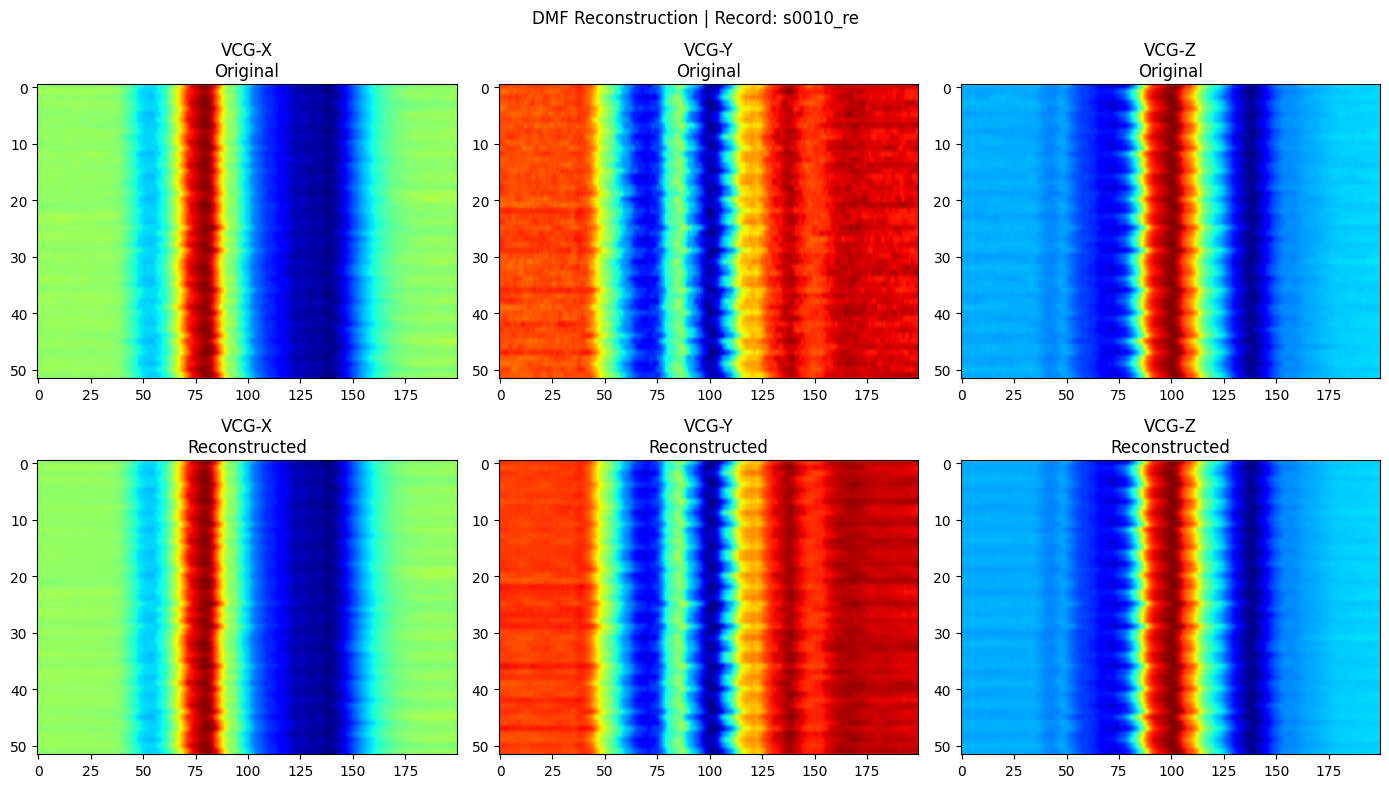

In [48]:
# =====================================================
# VISUALIZE DMF RECONSTRUCTION
# =====================================================

d=dmf_dataset[0]


print(

"Record:",

d["name"]

)



fig,ax=plt.subplots(

2,

3,

figsize=(14,8)

)



pairs=[

("Mx","Mx_rec","VCG-X"),

("My","My_rec","VCG-Y"),

("Mz","Mz_rec","VCG-Z")

]



for i,(orig,recon,title) in enumerate(

pairs

):


    im1=ax[0,i].imshow(

        d[orig],

        aspect='auto',

        cmap='jet'

    )


    ax[0,i].set_title(

f"{title}\nOriginal"

    )



    im2=ax[1,i].imshow(

        d[recon],

        aspect='auto',

        cmap='jet'

    )


    ax[1,i].set_title(

f"{title}\nReconstructed"

    )



plt.suptitle(

f"DMF Reconstruction | Record: {d['name']}"

)


plt.tight_layout()

plt.show()

In [49]:
# =====================================================
# METRIC FUNCTIONS
# =====================================================


EPS=1e-12



def PRD(

    original,

    reconstructed

):


    return np.sqrt(

        np.sum(

(original-reconstructed)**2

        )

        /

        (

np.sum(

original**2

)+EPS

        )

    )*100




def MSE(

    original,

    reconstructed

):


    return np.mean(

(original-reconstructed)**2

    )




def RMSE(

    original,

    reconstructed

):


    return np.sqrt(

        MSE(

original,

reconstructed

        )

    )




def MAE(

    original,

    reconstructed

):


    return np.mean(

np.abs(

original-reconstructed

)

    )




def SNR(

    original,

    reconstructed

):


    noise=(

original-

reconstructed

    )



    return 10*np.log10(

        (

np.sum(

original**2

)+EPS

        )

        /

        (

np.sum(

noise**2

)+EPS

        )

    )




def PSNR(

    original,

    reconstructed

):


    mse=MSE(

original,

reconstructed

    )


    peak=np.max(

np.abs(

original

)

    )



    return 20*np.log10(

        (

peak+EPS

        )

        /

        (

np.sqrt(

mse

)+EPS

        )

    )




def CC(

    original,

    reconstructed

):


    return np.corrcoef(

original.flatten(),

reconstructed.flatten()

    )[0,1]




def QS(

    cr,

    prd

):


    return cr/(

prd+EPS

    )

In [50]:
# =====================================================
# FULL METRICS TABLE
# =====================================================

results=[]


for d in dmf_dataset:


    original=np.concatenate([

        d["Mx"].flatten(),

        d["My"].flatten(),

        d["Mz"].flatten()

    ])



    reconstructed=np.concatenate([

        d["Mx_rec"].flatten(),

        d["My_rec"].flatten(),

        d["Mz_rec"].flatten()

    ])



    prd=PRD(

        original,

        reconstructed

    )


    mse=MSE(

        original,

        reconstructed

    )


    rmse=RMSE(

        original,

        reconstructed

    )


    mae=MAE(

        original,

        reconstructed

    )


    snr=SNR(

        original,

        reconstructed

    )


    psnr=PSNR(

        original,

        reconstructed

    )


    cc=CC(

        original,

        reconstructed

    )



    # ==========================
    # COMPRESSION RATIO
    # ==========================


    original_size=(

        d["Mx"].size+

        d["My"].size+

        d["Mz"].size

    )*8



    compressed_size=(

        d["Wx1"].size+

        d["Wx2"].size+

        d["Hx_latent"].size+

        d["Wy1"].size+

        d["Wy2"].size+

        d["Hy_latent"].size+

        d["Wz1"].size+

        d["Wz2"].size+

        d["Hz_latent"].size

    )*2



    cr=(

        original_size/

        compressed_size

    )



    qs=QS(

        cr,

        prd

    )



    # ==========================
    # TIMES
    # ==========================


    comp_time=np.mean([

        d["Compression_Time_X"],

        d["Compression_Time_Y"],

        d["Compression_Time_Z"]

    ])



    recon_time=np.mean([

        d["Reconstruction_Time_X"],

        d["Reconstruction_Time_Y"],

        d["Reconstruction_Time_Z"]

    ])



    combined_time=(

        comp_time+

        recon_time

    )



    results.append({


        "Record":

        d["name"],


        "PRD":

        round(prd,4),


        "CR":

        round(cr,4),


        "SNR":

        round(snr,4),


        "PSNR":

        round(psnr,4),


        "CC":

        round(cc,4),


        "MSE":

        round(mse,6),


        "RMSE":

        round(rmse,6),


        "MAE":

        round(mae,6),


        "QS":

        round(qs,4),


        "Compression_Time":

        round(comp_time,4),


        "Reconstruction_Time":

        round(recon_time,4),


        "Combined_Time":

        round(combined_time,4)

    })



results_df=pd.DataFrame(

    results

)



avg=results_df.mean(

numeric_only=True

)



avg["Record"]="Average"



results_df.loc[

len(

results_df

)

]=avg



print(

results_df
)

      Record        PRD         CR        SNR      PSNR        CC       MSE  \
0   s0010_re   2.627000  18.677000  31.610700  40.82410  0.999700  0.000690   
1   s0014lre  10.551500  37.215100  19.533700  31.42800  0.994400  0.011134   
2   s0016lre  12.554800  41.731600  18.023800  27.39660  0.992100  0.015762   
3   s0015lre   3.697900  33.431700  28.640800  40.31060  0.999300  0.001367   
4   s0017lre   4.910700  32.275500  26.177200  36.86910  0.998800  0.002411   
5   s0020are   8.740300  34.057800  21.169500  38.65190  0.996200  0.007639   
6   s0020bre   6.374100  33.793600  23.911700  35.65610  0.998000  0.004063   
7   s0021are   2.771500  36.119700  31.145600  42.75570  0.999600  0.000768   
8   s0021bre   2.953100  36.047300  30.594400  42.32170  0.999600  0.000872   
9   s0025lre   3.364400  37.018500  29.461700  42.12100  0.999400  0.001132   
10  s0031lre   3.807800  35.525700  28.386400  41.05960  0.999300  0.001450   
11  s0101lre   2.746700  30.775500  31.223700  43.80

Record: s0010_re
VCG-X Mean Error: 0.010809
VCG-Y Mean Error: 0.033127
VCG-Z Mean Error: 0.009471


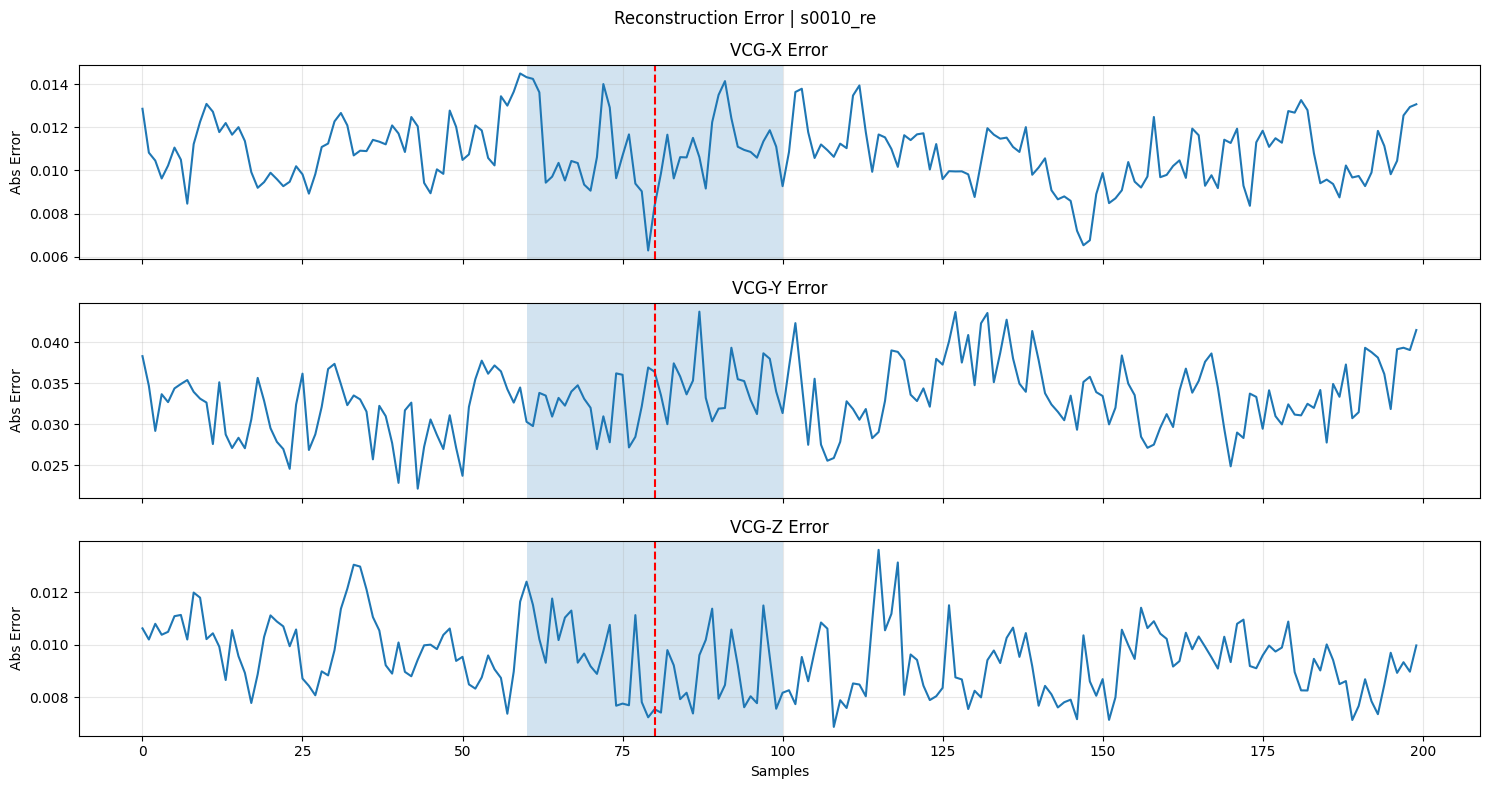

In [51]:
# =====================================================
# RECONSTRUCTION ERROR CURVES
# =====================================================

d=dmf_dataset[0]


print(

"Record:",

d["name"]

)



fig,ax=plt.subplots(

3,

1,

figsize=(15,8),

sharex=True

)



pairs=[

("Mx","Mx_rec","VCG-X"),

("My","My_rec","VCG-Y"),

("Mz","Mz_rec","VCG-Z")

]



for i,(orig,recon,title) in enumerate(

pairs

):



    err=np.mean(

        np.abs(

            d[orig]

            -

            d[recon]

        ),

        axis=0

    )



    ax[i].plot(

        err

    )



    # ==========================
    # R PEAK
    # ==========================


    ax[i].axvline(

        80,

        color='r',

        linestyle='--',

        label='R peak'

    )



    # ==========================
    # Approx QRS
    # ==========================


    ax[i].axvspan(

        60,

        100,

        alpha=0.2

    )



    ax[i].set_title(

f"{title} Error"

    )


    ax[i].set_ylabel(

"Abs Error"

    )


    ax[i].grid(

        alpha=0.3

    )



    print(

f"{title} Mean Error:",

round(

err.mean(),

6

)

    )



plt.xlabel(

"Samples"

)


plt.suptitle(

f"Reconstruction Error | {d['name']}"

)


plt.tight_layout()

plt.show()

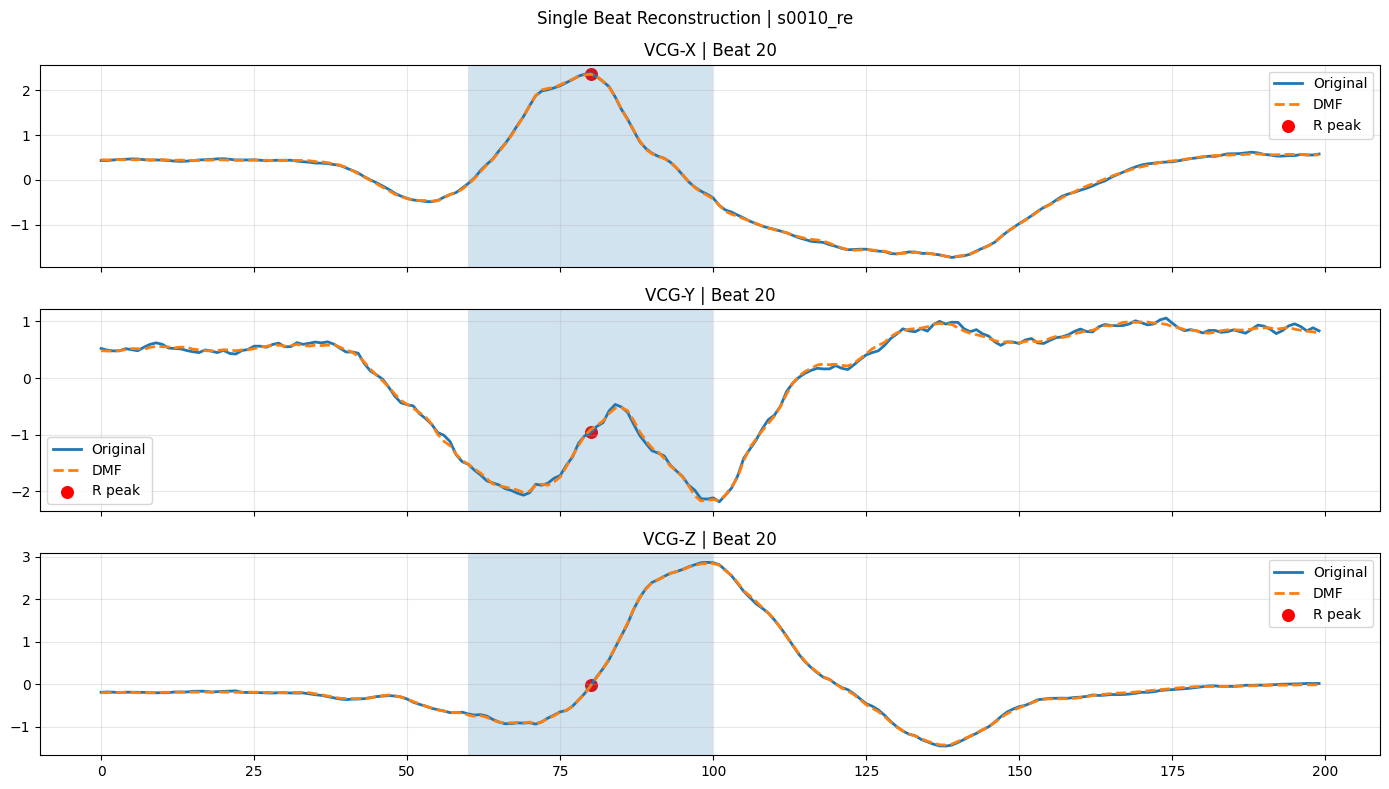

Record: s0010_re
Reference R peak: 80


In [70]:
# ============================================
# ORIGINAL vs RECONSTRUCTED (FIXED R PEAKS)
# ============================================

import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks


d=dmf_dataset[0]

name=d["name"]

beat_idx=20



signals=[

("Mx","Mx_rec","VCG-X"),

("My","My_rec","VCG-Y"),

("Mz","Mz_rec","VCG-Z")

]



# ============================================
# USE X LEAD FOR TRUE R PEAK
# ============================================


ref=d["Mx"][beat_idx]


r_peaks,_=find_peaks(

    ref,

    distance=30,

    prominence=np.std(ref)*0.5,

    height=np.mean(ref)

)



true_r=r_peaks[

    np.argmax(

        ref[r_peaks]

    )

]



fig,ax=plt.subplots(

3,

1,

figsize=(14,8),

sharex=True

)



for i,(orig_key,recon_key,title) in enumerate(

signals

):



    orig=d[orig_key][beat_idx]



    recon=d[recon_key][beat_idx]



    ax[i].plot(

        orig,

        label='Original',

        linewidth=2

    )



    ax[i].plot(

        recon,

        '--',

        label='DMF',

        linewidth=2

    )



    # ========================
    # SAME TRUE R PEAK
    # ========================


    ax[i].scatter(

        true_r,

        orig[true_r],

        color='red',

        s=70,

        label='R peak'

    )



    ax[i].axvspan(

        true_r-20,

        true_r+20,

        alpha=.2

    )



    ax[i].set_title(

f"{title} | Beat {beat_idx}"

    )



    ax[i].grid(

        alpha=.3

    )



    ax[i].legend()



plt.suptitle(

f"Single Beat Reconstruction | {name}"

)


plt.tight_layout()

plt.show()



print(

"Record:",

name

)


print(

"Reference R peak:",

true_r
)

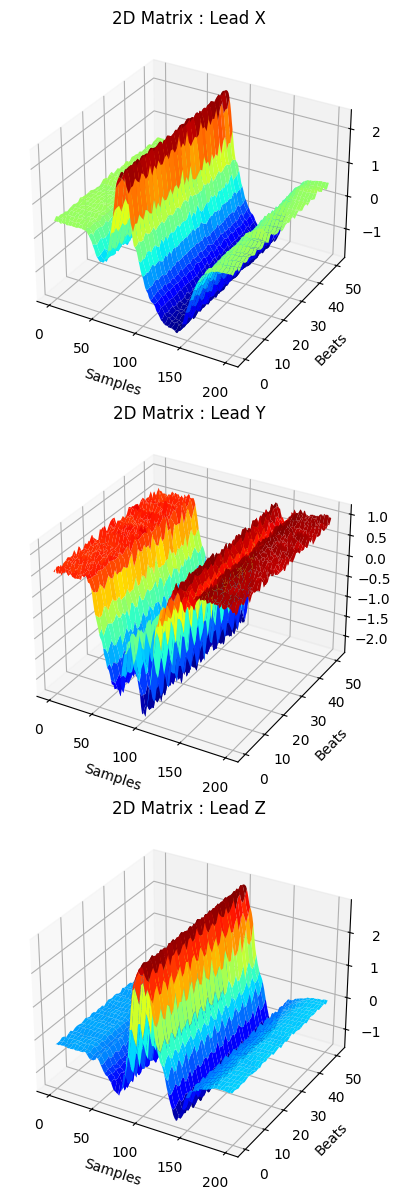

In [53]:
# =====================================================
# VCG TO 2D SURFACE
# =====================================================

from mpl_toolkits.mplot3d import Axes3D

d=aligned_dataset[0]

fig=plt.figure(figsize=(15,12))

matrices=[
    d["Mx"],
    d["My"],
    d["Mz"]
]

titles=["Lead X","Lead Y","Lead Z"]

for i,M in enumerate(matrices):

    ax=fig.add_subplot(
        3,
        2,
        2*i+2,
        projection='3d'
    )

    X,Y=np.meshgrid(

        np.arange(M.shape[1]),
        np.arange(M.shape[0])
    )

    ax.plot_surface(
        X,
        Y,
        M,
        cmap='jet'
    )

    ax.set_title(
        f"2D Matrix : {titles[i]}"
    )

    ax.set_xlabel("Samples")
    ax.set_ylabel("Beats")

plt.tight_layout()
plt.show()

Record: s0010_re


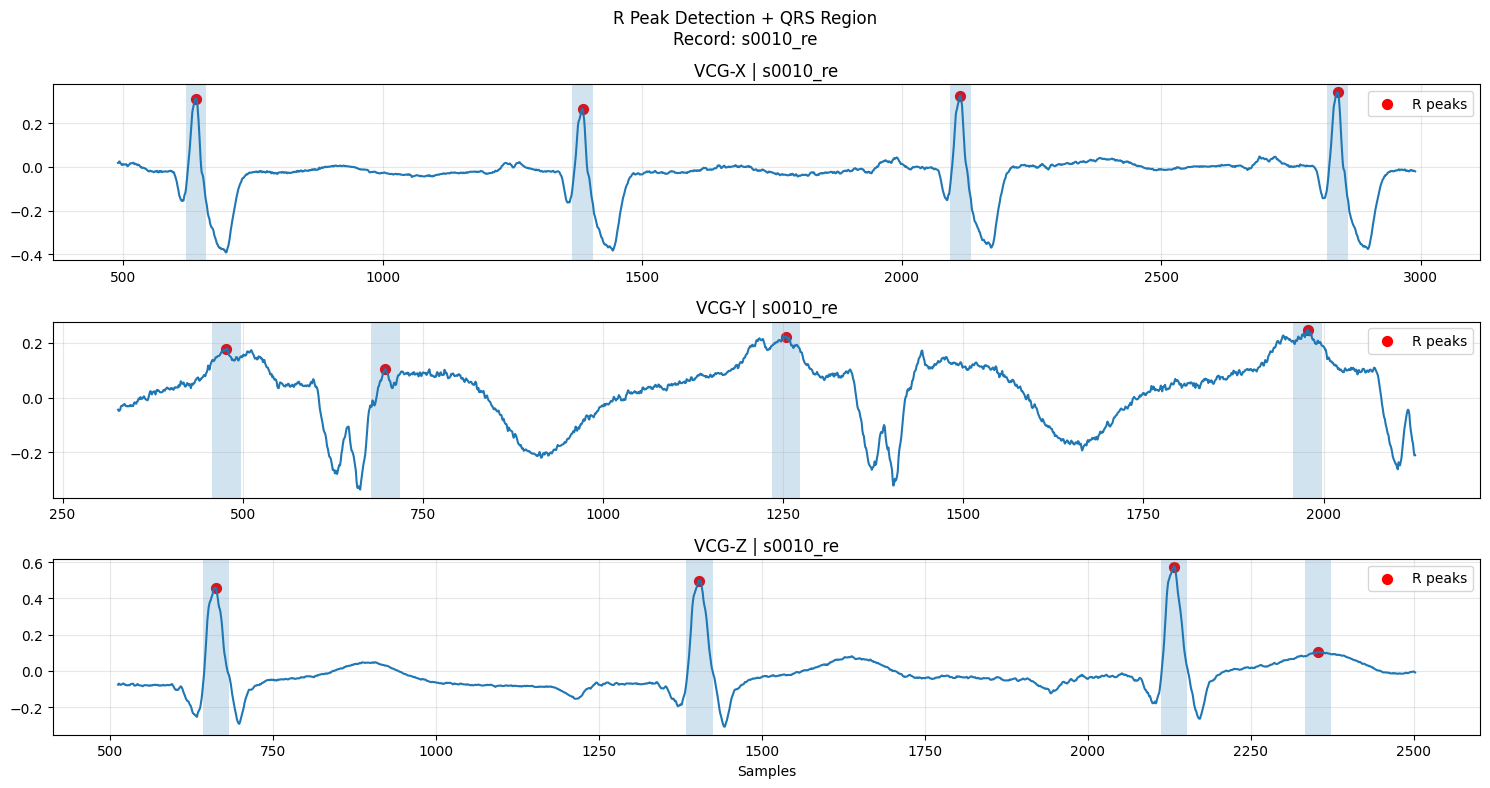

Saved: s0010_re_RPeak_QRS.png


In [54]:
# =====================================================
# R PEAK + QRS SHADING (2–3 BEATS)
# =====================================================

d=dataset[0]


print(

"Record:",

d["name"]

)



signals=[

    ("x","VCG-X"),

    ("y","VCG-Y"),

    ("z","VCG-Z")

]



fig,ax=plt.subplots(

    3,

    1,

    figsize=(15,8),

    sharex=False

)



for i,(lead,title) in enumerate(

    signals

):



    sig=d[lead]



    peaks,_=find_peaks(

        sig,

        distance=200,

        prominence=0.3

    )



    beats_to_show=3



    start=max(

        peaks[0]-150,

        0

    )



    end=min(

        peaks[beats_to_show]+150,

        len(sig)

    )



    segment=sig[

        start:end

    ]



    ax[i].plot(

        np.arange(

            start,

            end

        ),

        segment,

        linewidth=1.5

    )



    shown_peaks=[

        p for p in peaks

        if start<=p<=end

    ]



    # ======================
    # RED R PEAKS
    # ======================


    ax[i].scatter(

        shown_peaks,

        sig[shown_peaks],

        color='red',

        s=50,

        label="R peaks"

    )



    # ======================
    # SHADE QRS
    # ======================


    for p in shown_peaks:


        ax[i].axvspan(

            p-20,

            p+20,

            alpha=0.2

        )



    ax[i].set_title(

f"{title} | {d['name']}"

    )



    ax[i].grid(

        alpha=0.3

    )



    ax[i].legend()



plt.xlabel(

"Samples"

)


plt.suptitle(

f"R Peak Detection + QRS Region\nRecord: {d['name']}"

)


plt.tight_layout()



plt.savefig(

f"{d['name']}_RPeak_QRS.png",

dpi=300

)



plt.show()



print(

"Saved:",

f"{d['name']}_RPeak_QRS.png"

)

Record: s0010_re


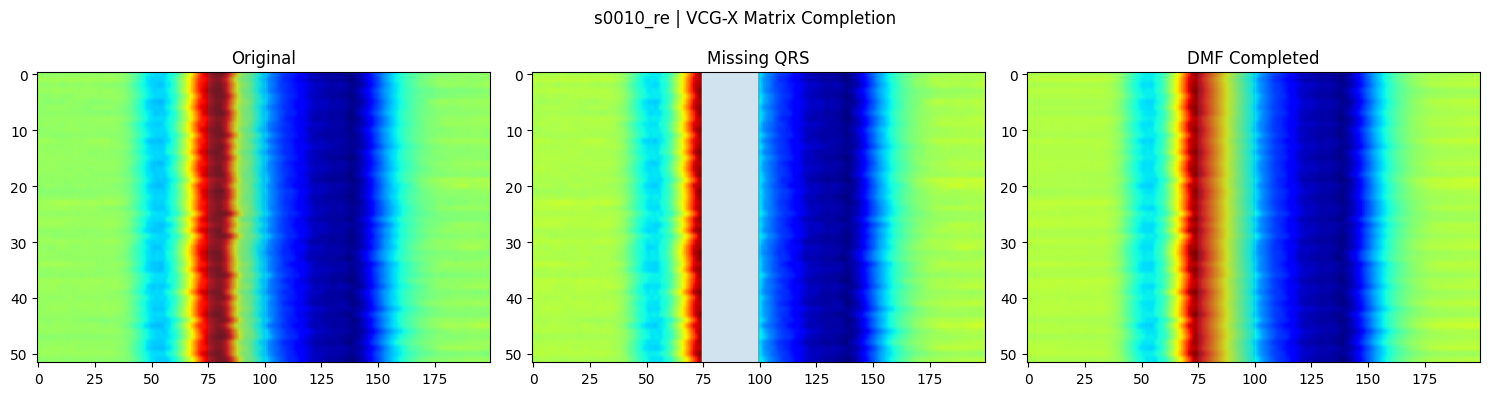

In [55]:
# ============================================
# MATRIX COMPLETION (ONLY VCG-X) — FIXED
# ============================================

record=dmf_dataset[0]


print(

"Record:",

record["name"]

)



M=record["Mx"]



gap=M.copy()



GAP_START=75
GAP_END=100



gap[:,

GAP_START:GAP_END

]=np.nan



interp=gap.copy()



for r in range(

interp.shape[0]

):


    row=interp[r]


    x=np.arange(

        len(row)

    )


    valid=~np.isnan(

        row

    )



    row[

        np.isnan(

            row

        )

    ]=np.interp(

        x[

            np.isnan(

                row

            )

        ],

        x[

            valid

        ],

        row[

            valid

        ]

    )



    interp[r]=row



# ==========================
# DMF COMPLETION
# ==========================


completed,_,_,_,_=deep_matrix_factorization(

    interp,

    r1=12,

    r2=6,

    iterations=200

)



plt.figure(

figsize=(15,4)

)



titles=[

"Original",

"Missing QRS",

"DMF Completed"

]



for i,X in enumerate(

[

M,

gap,

completed

]

):



    plt.subplot(

1,

3,

i+1

)



    plt.imshow(

        X,

        aspect='auto',

        cmap='jet'

    )



    plt.axvspan(

        GAP_START,

        GAP_END,

        alpha=.2

    )



    plt.title(

titles[i]

    )



plt.suptitle(

f"{record['name']} | VCG-X Matrix Completion"

)



plt.tight_layout()

plt.show()

In [56]:
# =====================================================
# TABLE 9 EXPORT (LEAD-WISE + TIME + FIXED CR)
# =====================================================

import os
import numpy as np
import pandas as pd


rows=[]

EPS=1e-12



for d in dmf_dataset:


    rec=d["name"]

    temp=[]



    lead_pairs=[

        ("Vx","Mx","Mx_rec","X"),

        ("Vy","My","My_rec","Y"),

        ("Vz","Mz","Mz_rec","Z")

    ]



    for lead,orig_key,recon_key,time_key in lead_pairs:



        orig=d[orig_key].flatten()

        recon=d[recon_key].flatten()



        # ==================================
        # METRICS
        # ==================================


        mse=np.mean(

            (orig-recon)**2

        )



        prd1d=100*np.sqrt(

            np.sum(

                (orig-recon)**2

            )

            /

            (

                np.sum(

                    orig**2

                )

                +

                EPS

            )

        )



        snr1d=10*np.log10(

            (

                np.sum(

                    orig**2

                )

                +

                EPS

            )

            /

            (

                np.sum(

                    (orig-recon)**2

                )

                +

                EPS

            )

        )



        psnr1d=20*np.log10(

            (

                np.max(

                    np.abs(

                        orig

                    )

                )

                +

                EPS

            )

            /

            (

                np.sqrt(

                    mse

                )

                +

                EPS

            )

        )



        cc=np.corrcoef(

            orig,

            recon

        )[0,1]



        # ==================================
        # FIXED LEAD-WISE CR
        # ==================================


        compressed=(

            d[f"W{time_key.lower()}1"].size

            +

            d[f"W{time_key.lower()}2"].size

            +

            d[f"H{time_key.lower()}_latent"].size

        )*2      # float16 bytes



        original=(

            d[orig_key].size

        )*8       # float64 bytes



        cr=original/compressed



        qs1d=cr/(

            prd1d+

            EPS

        )



        # ==================================
        # STORE
        # ==================================


        row={


            "Record":

            rec,


            "Lead":

            lead,


            "CR":

            round(

                cr,

                4

            ),


            "PRD1D":

            round(

                prd1d,

                4

            ),


            "SNR1D":

            round(

                snr1d,

                4

            ),


            "PSNR1D":

            round(

                psnr1d,

                4

            ),


            "QS1D":

            round(

                qs1d,

                4

            ),


            "MSE":

            round(

                mse,

                6

            ),


            "CC":

            round(

                cc,

                4

            ),



            "Compression_Time":

            round(

                d[f"Compression_Time_{time_key}"],

                4

            ),


            "Reconstruction_Time":

            round(

                d[f"Reconstruction_Time_{time_key}"],

                4

            ),


            "Combined_Time":

            round(

                d[f"Combined_Time_{time_key}"],

                4

            )

        }



        rows.append(

            row

        )


        temp.append(

            row

        )



    # ==================================
    # RECORD AVERAGE
    # ==================================


    avg={

        "Record":

        rec,


        "Lead":

        "Avg"

    }



    numeric=[

        "CR",

        "PRD1D",

        "SNR1D",

        "PSNR1D",

        "QS1D",

        "MSE",

        "CC",

        "Compression_Time",

        "Reconstruction_Time",

        "Combined_Time"

    ]



    for col in numeric:


        avg[col]=np.mean(

            [

                x[col]

                for x in temp

            ]

        )



    rows.append(

        avg

    )



# ==================================
# FINAL DF
# ==================================


final_df=pd.DataFrame(

    rows

)



# ==================================
# OVERALL AVG
# ==================================


overall={

    "Record":

    "Overall",


    "Lead":

    "Average"

}



for col in numeric:


    overall[col]=final_df.loc[

        final_df["Lead"]=="Avg",

        col

    ].mean()



final_df.loc[

    len(

        final_df

    )

]=overall



# ==================================
# SAVE
# ==================================


save_path=os.path.join(

    os.getcwd(),

    "DMF_Table9_Final_FIXED_CR.xlsx"

)



final_df.to_excel(

    save_path,

    index=False

)



print(

"\nSaved:",

save_path

)



print(

"\nOverall:\n"

)



print(

final_df.tail()
)


Saved: /kaggle/working/DMF_Table9_Final_FIXED_CR.xlsx

Overall:

      Record     Lead         CR     PRD1D      SNR1D     PSNR1D       QS1D  \
56  s0064lre       Vx  28.988300  1.435600  36.859600  47.633900  20.193100   
57  s0064lre       Vy  38.954200  6.009100  24.423800  35.345500   6.482600   
58  s0064lre       Vz  33.258900  1.277300  37.873900  47.304700  26.037800   
59  s0064lre      Avg  33.733800  2.907333  33.052433  43.428033  17.571167   
60   Overall  Average  34.445056  4.442624  30.024289  40.325669  13.400582   

         MSE        CC  Compression_Time  Reconstruction_Time  Combined_Time  
56  0.000206  0.999900          0.010600             0.000000       0.010600  
57  0.003611  0.998200          0.009700             0.000000       0.009700  
58  0.000163  0.999900          0.009600             0.000000       0.009700  
59  0.001327  0.999333          0.009967             0.000000       0.010000  
60  0.003609  0.998189          0.011851             0.000044   

In [57]:
# =====================================================
# TABLE 9 EXPORT (FIXED LEAD-WISE CR + TIME)
# =====================================================

import os
import numpy as np
import pandas as pd


rows=[]

EPS=1e-12



for d in dmf_dataset:


    rec=d["name"]

    temp=[]



    lead_pairs=[

        ("Vx","Mx","Mx_rec","X"),

        ("Vy","My","My_rec","Y"),

        ("Vz","Mz","Mz_rec","Z")

    ]



    for lead,orig_key,recon_key,time_key in lead_pairs:



        orig=d[orig_key].flatten()

        recon=d[recon_key].flatten()



        mse=np.mean(

            (orig-recon)**2

        )



        prd1d=100*np.sqrt(

            np.sum(

                (orig-recon)**2

            )

            /

            (

                np.sum(

                    orig**2

                )

                +

                EPS

            )

        )



        snr1d=10*np.log10(

            (

                np.sum(

                    orig**2

                )

                +

                EPS

            )

            /

            (

                np.sum(

                    (orig-recon)**2

                )

                +

                EPS

            )

        )



        psnr1d=20*np.log10(

            (

                np.max(

                    np.abs(

                        orig

                    )

                )

                +

                EPS

            )

            /

            (

                np.sqrt(

                    mse

                )

                +

                EPS

            )

        )



        cc=np.corrcoef(

            orig,

            recon

        )[0,1]



        # ==================================
        # FIXED LEAD-WISE CR
        # ==================================


        compressed=(

            d[f"W{time_key.lower()}1"].size

            +

            d[f"W{time_key.lower()}2"].size

            +

            d[f"H{time_key.lower()}_latent"].size

        )*2     # float16 bytes



        original=(

            d[orig_key].size

        )*8      # float64 bytes



        cr=original/compressed



        qs1d=cr/(

            prd1d+

            EPS

        )



        row={

            "Record":rec,

            "Lead":lead,

            "CR":round(cr,4),

            "PRD1D":round(prd1d,4),

            "SNR1D":round(snr1d,4),

            "PSNR1D":round(psnr1d,4),

            "QS1D":round(qs1d,4),

            "MSE":round(mse,6),

            "CC":round(cc,4),


            "Compression_Time":

            round(

                d[f"Compression_Time_{time_key}"],

                4

            ),


            "Reconstruction_Time":

            round(

                d[f"Reconstruction_Time_{time_key}"],

                4

            ),


            "Combined_Time":

            round(

                d[f"Combined_Time_{time_key}"],

                4

            )

        }



        rows.append(

            row

        )


        temp.append(

            row

        )



    avg={

        "Record":

        rec,

        "Lead":

        "Avg"

    }



    numeric_cols=[

        "CR",

        "PRD1D",

        "SNR1D",

        "PSNR1D",

        "QS1D",

        "MSE",

        "CC",

        "Compression_Time",

        "Reconstruction_Time",

        "Combined_Time"

    ]



    for c in numeric_cols:


        avg[c]=np.mean(

            [

                x[c]

                for x in temp

            ]

        )



    rows.append(

        avg

    )



final_df=pd.DataFrame(

    rows

)



overall={

    "Record":

    "Overall",

    "Lead":

    "Average"

}



for c in numeric_cols:


    overall[c]=final_df.loc[

        final_df["Lead"]=="Avg",

        c

    ].mean()



final_df.loc[

    len(

        final_df

    )

]=overall



save_path=os.path.join(

    os.getcwd(),

    "DMF_Table9_Time_FIXED.xlsx"

)



final_df.to_excel(

    save_path,

    index=False

)



print(

"Saved:",

save_path

)



print(

"\nOverall:\n"

)



print(

final_df.tail()
)

Saved: /kaggle/working/DMF_Table9_Time_FIXED.xlsx

Overall:

      Record     Lead         CR     PRD1D      SNR1D     PSNR1D       QS1D  \
56  s0064lre       Vx  28.988300  1.435600  36.859600  47.633900  20.193100   
57  s0064lre       Vy  38.954200  6.009100  24.423800  35.345500   6.482600   
58  s0064lre       Vz  33.258900  1.277300  37.873900  47.304700  26.037800   
59  s0064lre      Avg  33.733800  2.907333  33.052433  43.428033  17.571167   
60   Overall  Average  34.445056  4.442624  30.024289  40.325669  13.400582   

         MSE        CC  Compression_Time  Reconstruction_Time  Combined_Time  
56  0.000206  0.999900          0.010600             0.000000       0.010600  
57  0.003611  0.998200          0.009700             0.000000       0.009700  
58  0.000163  0.999900          0.009600             0.000000       0.009700  
59  0.001327  0.999333          0.009967             0.000000       0.010000  
60  0.003609  0.998189          0.011851             0.000044       0

Record: s0010_re

Lead X
Top 5 singular values:
[101.81216831   4.34624594   2.51188199   1.92921204   1.56540616]

Lead Y
Top 5 singular values:
[101.50774967   7.45198158   3.21961077   2.30299928   2.04216938]

Lead Z
Top 5 singular values:
[101.52559987   8.95794843   2.77544388   1.33624547   0.89108132]


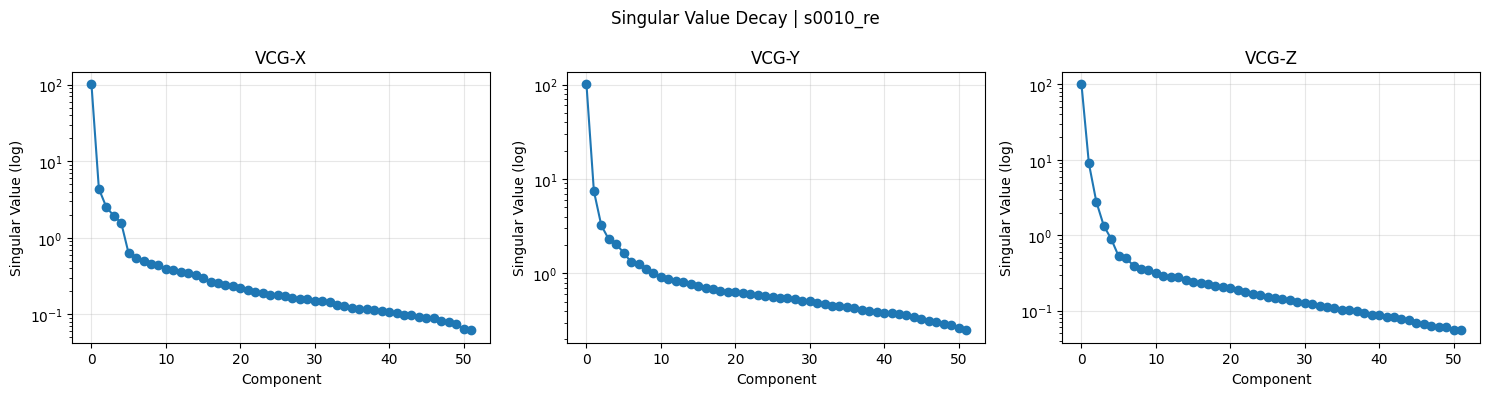

In [58]:
# =====================================================
# SINGULAR VALUE DECAY ANALYSIS
# =====================================================

d=aligned_dataset[0]


print(

"Record:",

d["name"]

)



fig,ax=plt.subplots(

1,

3,

figsize=(15,4)

)



for i,(lead,matrix) in enumerate([

    ("X",d["Mx"]),

    ("Y",d["My"]),

    ("Z",d["Mz"])

]):



    U,S,VT=np.linalg.svd(

        matrix,

        full_matrices=False

    )



    ax[i].semilogy(

        S,

        marker='o'

    )



    ax[i].set_title(

f"VCG-{lead}"

    )



    ax[i].set_xlabel(

"Component"

    )



    ax[i].set_ylabel(

"Singular Value (log)"

    )



    ax[i].grid(

        alpha=0.3

    )



    print(

f"\nLead {lead}"

    )



    print(

"Top 5 singular values:"

    )



    print(

S[:5]

    )



plt.suptitle(

f"Singular Value Decay | {d['name']}"

)


plt.tight_layout()

plt.show()

Record: s0010_re
Mx Mean variability: 0.0509
My Mean variability: 0.0873
Mz Mean variability: 0.0675


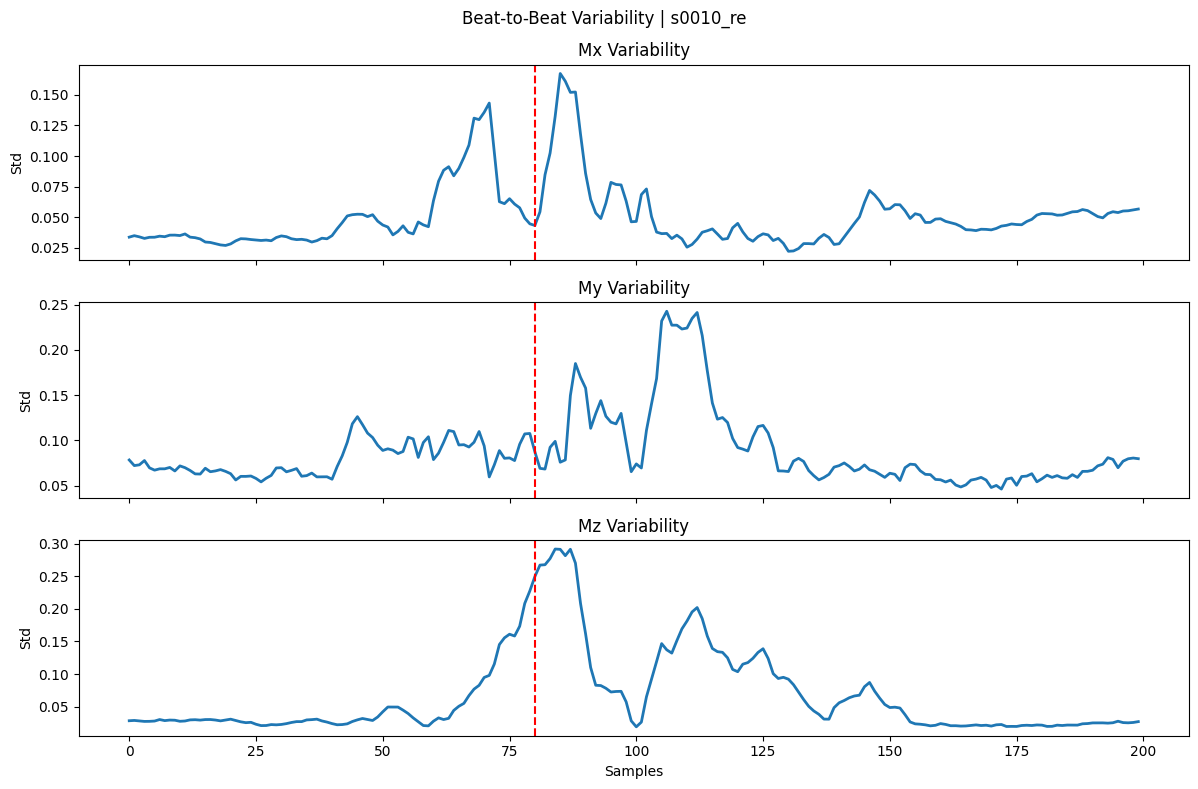

In [59]:
# =====================================================
# BEAT VARIABILITY ANALYSIS
# =====================================================

d=aligned_dataset[0]


print(

"Record:",

d["name"]

)



fig,ax=plt.subplots(

3,

1,

figsize=(12,8),

sharex=True

)



for i,lead in enumerate(

["Mx","My","Mz"]

):



    M=d[lead]



    variability=np.std(

        M,

        axis=0

    )



    ax[i].plot(

        variability,

        linewidth=2

    )



    ax[i].axvline(

        80,

        color='r',

        linestyle='--'

    )



    ax[i].set_title(

f"{lead} Variability"

    )



    ax[i].set_ylabel(

"Std"

    )



    print(

lead,

"Mean variability:",

round(

variability.mean(),

4

)

    )



plt.xlabel(

"Samples"

)


plt.suptitle(

f"Beat-to-Beat Variability | {d['name']}"

)


plt.tight_layout()

plt.show()

In [60]:
# =====================================================
# ADVANCED EFFECTIVE RANK ANALYSIS
# =====================================================

import numpy as np
import pandas as pd


d=aligned_dataset[0]


print(

"Record:",

d["name"]

)



results=[]



for lead,M in [

    ("X",d["Mx"]),

    ("Y",d["My"]),

    ("Z",d["Mz"])

]:



    U,S,VT=np.linalg.svd(

        M,

        full_matrices=False

    )



    energy=np.cumsum(

        S**2

    )/np.sum(

        S**2

    )



    rank95=np.argmax(

        energy>=0.95

    )+1



    rank99=np.argmax(

        energy>=0.99

    )+1



    rank999=np.argmax(

        energy>=0.999

    )+1



    stable=np.sum(

        S**2

    )/(

        S[0]**2

    )



    probs=(

        S**2

    )/np.sum(

        S**2

    )



    entropy=np.exp(

        -np.sum(

            probs*

            np.log(

                probs+

                1e-12

            )

        )

    )



    results.append({

        "Lead":

        lead,


        "Exact Rank":

        np.linalg.matrix_rank(

            M

        ),


        "Rank95":

        rank95,


        "Rank99":

        rank99,


        "Rank99.9":

        rank999,


        "Stable Rank":

        round(

            stable,

            2

        ),


        "Entropy Rank":

        round(

            entropy,

            2

        ),


        "Suggested r1":

        rank99,


        "Suggested r2":

        max(

            2,

            rank99//2

        )

    })



rank_df=pd.DataFrame(

    results

)



print(

"\nAdvanced Rank Metrics:\n"

)



print(

rank_df

)



save_path=(

"/kaggle/working/Rank_Analysis.xlsx"

)



rank_df.to_excel(

    save_path,

    index=False

)



print(

"\nSaved:",

save_path

)

Record: s0010_re

Advanced Rank Metrics:

  Lead  Exact Rank  Rank95  Rank99  Rank99.9  Stable Rank  Entropy Rank  \
0    X          52       1       1         3         1.00          1.03   
1    Y          52       1       1        13         1.01          1.07   
2    Z          52       1       1         3         1.01          1.06   

   Suggested r1  Suggested r2  
0             1             2  
1             1             2  
2             1             2  

Saved: /kaggle/working/Rank_Analysis.xlsx



Record: s0010_re
Detected peaks: 52


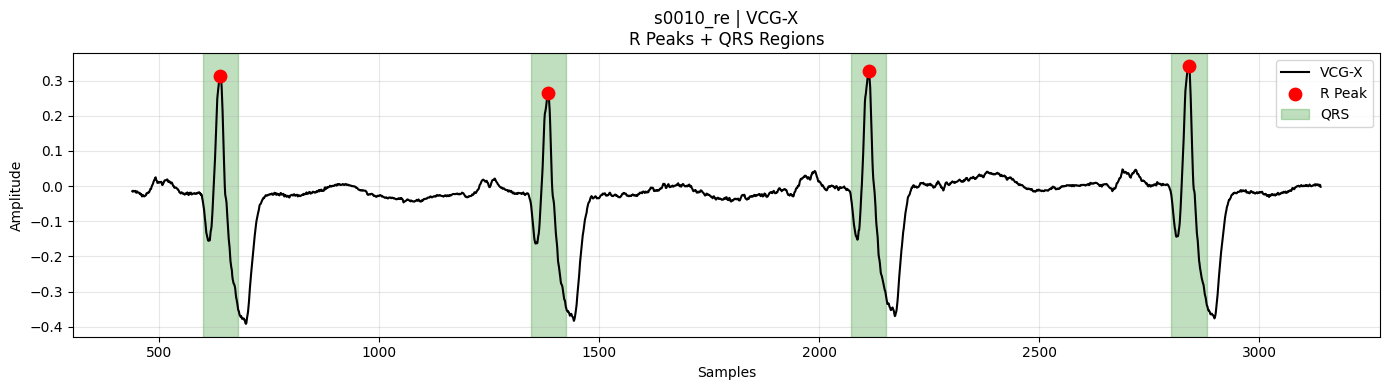


Shown beats: 3
Saved: /kaggle/working/s0010_re_RPeak_QRS.png


In [61]:
# ============================================
# R PEAK + QRS VISUALIZATION (FINAL)
# ============================================

import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks


record=dataset[0]

sig=record["x"]

name=record["name"]


print(

"\nRecord:",

name

)



# ============================================
# R PEAK DETECTION
# ============================================


r_peaks,_=find_peaks(

    sig,

    distance=500,

    prominence=1.5*np.std(sig),

    height=np.mean(sig)+0.5*np.std(sig)

)


print(

"Detected peaks:",

len(

    r_peaks

)

)



# ============================================
# SHOW 3 BEATS
# ============================================


beats_to_show=min(

    3,

    len(

        r_peaks

    )-1

)



start=max(

    0,

    r_peaks[0]-200

)



end=min(

    len(sig),

    r_peaks[beats_to_show]+300

)



segment=sig[

    start:end

]



plt.figure(

    figsize=(14,4)

)



plt.plot(

    np.arange(

        start,

        end

    ),

    segment,

    color='black',

    linewidth=1.5,

    label="VCG-X"

)



shown=[

    p for p in r_peaks

    if start<=p<=end

]



for rp in shown:



    # ==========================
    # RED R PEAK
    # ==========================


    plt.scatter(

        rp,

        sig[rp],

        color='red',

        s=80,

        zorder=5,

        label="R Peak"

    )



    # ==========================
    # SHADE QRS
    # ==========================


    plt.axvspan(

        rp-40,

        rp+40,

        alpha=0.25,

        color='green',

        label="QRS"

    )



plt.title(

f"{name} | VCG-X\nR Peaks + QRS Regions"

)



plt.xlabel(

"Samples"

)



plt.ylabel(

"Amplitude"

)



plt.grid(

    alpha=0.3

)



handles,labels=plt.gca().get_legend_handles_labels()



by_label=dict(

    zip(

        labels,

        handles

    )

)



plt.legend(

    by_label.values(),

    by_label.keys()

)



plt.tight_layout()



save_path=(

f"/kaggle/working/{name}_RPeak_QRS.png"

)



plt.savefig(

    save_path,

    dpi=300

)



plt.show()



print(

"\nShown beats:",

beats_to_show

)



print(

"Saved:",

save_path

)

In [62]:
# ============================================
# RECORD INFO FOR FIGURES/TABLES
# ============================================

record=dataset[0]     # or aligned_dataset[0]


print(

"\n==================================="

)


print(

"Record Used:",

record["name"]

)



if "x" in record:


    print(

        "Raw Shape:",

        record["x"].shape

    )



if "Mx" in record:


    print(

        "Aligned Matrix Shape:",

        record["Mx"].shape

    )



print(

"Available Keys:",

list(

    record.keys()

)

)



print(

"===================================\n"

)


Record Used: s0010_re
Raw Shape: (38400,)
Available Keys: ['name', 'x', 'y', 'z']



In [63]:
# ============================================
# CREATE OUTPUT DIRECTORIES
# ============================================

import os


BASE_DIR=os.getcwd()



FIG_DIR=os.path.join(

    BASE_DIR,

    "Figures"

)



EXCEL_DIR=os.path.join(

    BASE_DIR,

    "Excels"

)



MODEL_DIR=os.path.join(

    BASE_DIR,

    "Results"

)



for folder in [

    FIG_DIR,

    EXCEL_DIR,

    MODEL_DIR

]:

    os.makedirs(

        folder,

        exist_ok=True

    )



print(

"\nCreated folders:\n"

)



print(

"Figures:",

FIG_DIR

)



print(

"Excels:",

EXCEL_DIR

)



print(

"Results:",

MODEL_DIR
)


Created folders:

Figures: /kaggle/working/Figures
Excels: /kaggle/working/Excels
Results: /kaggle/working/Results


In [64]:
top10=results_df.sort_values(

    "PRD"

).head(10)



print(

top10[

["Record","PRD","CR"]

]

)



top10.to_excel(

os.path.join(

EXCEL_DIR,

"Top10_Records.xlsx"

),

index=False
)

      Record     PRD       CR
0   s0010_re  2.6270  18.6770
11  s0101lre  2.7467  30.7755
7   s0021are  2.7715  36.1197
8   s0021bre  2.9531  36.0473
9   s0025lre  3.3644  37.0185
14  s0064lre  3.6424  33.2466
3   s0015lre  3.6979  33.4317
10  s0031lre  3.8078  35.5257
12  s0022lre  4.2241  35.5257
4   s0017lre  4.9107  32.2755


In [65]:
# ============================================
# CHECK SUSPICIOUS RECORDS
# ============================================

sus=results_df[

    (results_df["PRD"]<0.5)

    |

    (results_df["CC"]>0.9999)

]



print(

"\nSuspicious records:\n"

)



print(

sus[

["Record","PRD","CR","CC"]

]

)


Suspicious records:

Empty DataFrame
Columns: [Record, PRD, CR, CC]
Index: []


In [66]:
# ============================================
# WORST RECORDS
# ============================================

worst=results_df.sort_values(

"PRD",

ascending=False

).head(

5

)



print(

"\nWorst records:\n"

)



print(

worst[

["Record","PRD","CR","SNR"]

]

)


Worst records:

      Record      PRD       CR      SNR
2   s0016lre  12.5548  41.7316  18.0238
1   s0014lre  10.5515  37.2151  19.5337
5   s0020are   8.7403  34.0578  21.1695
6   s0020bre   6.3741  33.7936  23.9117
13  s0027lre   5.4542  33.7936  25.2654


In [67]:
# ============================================
# BEST vs WORST RECORD
# ============================================

best=results_df.sort_values(

"PRD"

).iloc[0]



worst=results_df.sort_values(

"PRD",

ascending=False

).iloc[0]



print(

"Best:",

best["Record"]

)



print(

"Worst:",

worst["Record"]

)

Best: s0010_re
Worst: s0016lre


In [68]:
# ============================================
# LEAD-WISE PRD
# ============================================

lead_avg=final_df.groupby(

"Lead"

)[

"PRD1D"

].mean()



print(

"\nLead Average PRD:\n"

)



print(

lead_avg
)


Lead Average PRD:

Lead
Average    4.442624
Avg        4.442624
Vx         3.444113
Vy         7.443073
Vz         2.440687
Name: PRD1D, dtype: float64


In [71]:
# ============================================
# LEAD-WISE PRD CHECK
# ============================================

for lead in [

("X","Mx","Mx_rec"),

("Y","My","My_rec"),

("Z","Mz","Mz_rec")

]:


    name,orig,recon=lead



    prd=100*np.sqrt(

        np.sum(

            (dmf_dataset[0][orig]-

             dmf_dataset[0][recon])**2

        )

        /

        np.sum(

            dmf_dataset[0][orig]**2

        )

    )



    print(

f"{name} PRD:",

round(

prd,

2

)

)

X PRD: 1.38
Y PRD: 4.17
Z PRD: 1.2


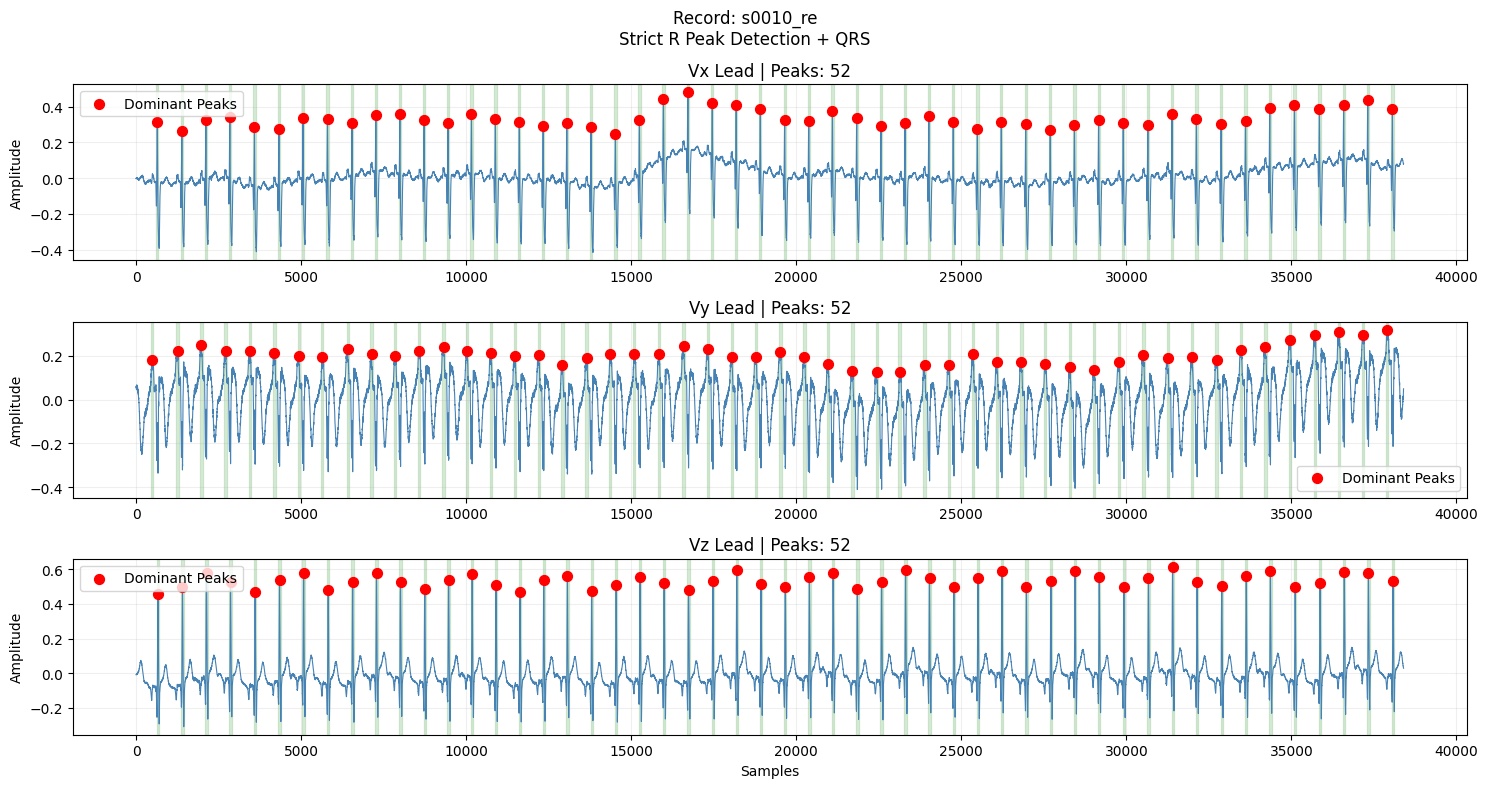


Saved: /kaggle/working/Figures/s0010_re_Strict_RPeaks.png


In [74]:
# ============================================
# STRICT R PEAK DETECTION (TA FIX)
# ONLY TRUE DOMINANT CARDIAC PEAKS
# ============================================

import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks


record=dataset[0]


signals=[

("Vx",record["x"]),

("Vy",record["y"]),

("Vz",record["z"])

]



plt.figure(

figsize=(15,8)

)



for i,(lead,sig) in enumerate(

signals

):



    plt.subplot(

3,

1,

i+1

)



    plt.plot(

        sig,

        linewidth=.8,

        color='steelblue'

    )



    # ==================================
    # STRICT PEAK DETECTION
    # ==================================

    peaks,_=find_peaks(

        sig,


        distance=600,


        prominence=1.8*np.std(

            sig

        ),


        height=np.mean(

            sig

        )+0.75*np.std(

            sig

        )

    )



    plt.scatter(

        peaks,

        sig[peaks],

        color='red',

        s=50,

        zorder=5,

        label='Dominant Peaks'

    )



    # ==================================
    # SHADE QRS REGION
    # ==================================

    for p in peaks:



        plt.axvspan(

            p-35,

            p+35,

            alpha=.15,

            color='green'

        )



    plt.title(

f"{lead} Lead | Peaks: {len(peaks)}"

    )



    plt.ylabel(

"Amplitude"

    )



    plt.grid(

        alpha=.2

    )



    plt.legend()



plt.xlabel(

"Samples"

)



plt.suptitle(

f"Record: {record['name']}\nStrict R Peak Detection + QRS"

)



plt.tight_layout()



save_path=os.path.join(

    FIG_DIR,

f"{record['name']}_Strict_RPeaks.png"

)



plt.savefig(

    save_path,

    dpi=300

)



plt.show()



print(

"\nSaved:",

save_path
)

In [75]:
# ============================================
# FIND WHY HIGH PRD RECORDS EXIST
# ============================================

worst=results_df.sort_values(

"PRD",

ascending=False

).head(

5

)



print(

"\nWorst PRD records:\n"

)



print(

worst[

["Record","PRD","CR","SNR"]

]

)



for rec in worst["Record"]:



    idx=[

        i for i,d in enumerate(

            dmf_dataset

        )

        if d["name"]==rec

    ][0]



    d=dmf_dataset[idx]



    print(

"\n",

rec

)



    for lead in [

("X","Mx"),

("Y","My"),

("Z","Mz")

]:



        name,key=lead



        variability=np.std(

            d[key],

            axis=0

        ).mean()



        print(

f"{name} variability:",

round(

variability,

4

)

)


Worst PRD records:

      Record      PRD       CR      SNR
2   s0016lre  12.5548  41.7316  18.0238
1   s0014lre  10.5515  37.2151  19.5337
5   s0020are   8.7403  34.0578  21.1695
6   s0020bre   6.3741  33.7936  23.9117
13  s0027lre   5.4542  33.7936  25.2654

 s0016lre
X variability: 0.5912
Y variability: 0.4689
Z variability: 0.5229

 s0014lre
X variability: 0.4721
Y variability: 0.5126
Z variability: 0.4774

 s0020are
X variability: 0.0444
Y variability: 0.4015
Z variability: 0.0598

 s0020bre
X variability: 0.0555
Y variability: 0.4166
Z variability: 0.0782

 s0027lre
X variability: 0.0476
Y variability: 0.1385
Z variability: 0.0397


In [76]:
# ============================================
# CHECK EFFECTIVE RANK OF WORST RECORDS
# ============================================

worst=[

"s0016lre",

"s0014lre",

"s0020are",

"s0020bre",

"s0027lre"

]



for rec in worst:



    idx=[

        i for i,d in enumerate(

            aligned_dataset

        )

        if d["name"]==rec

    ][0]



    d=aligned_dataset[idx]



    print(

"\n",

rec

)



    for lead in [

("X","Mx"),

("Y","My"),

("Z","Mz")

]:



        name,key=lead



        U,S,VT=np.linalg.svd(

            d[key],

            full_matrices=False

        )



        energy=np.cumsum(

            S**2

        )/np.sum(

            S**2

        )



        rank95=np.argmax(

            energy>=0.95

        )+1



        print(

f"{name} Rank95:",

rank95

)


 s0016lre
X Rank95: 2
Y Rank95: 3
Z Rank95: 2

 s0014lre
X Rank95: 3
Y Rank95: 2
Z Rank95: 3

 s0020are
X Rank95: 1
Y Rank95: 4
Z Rank95: 1

 s0020bre
X Rank95: 1
Y Rank95: 4
Z Rank95: 1

 s0027lre
X Rank95: 1
Y Rank95: 1
Z Rank95: 1


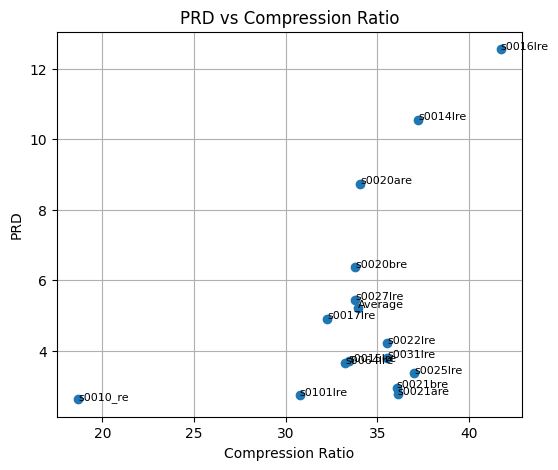

In [77]:
# ============================================
# PRD vs CR RELATION
# ============================================

plt.figure(

figsize=(6,5)

)



plt.scatter(

results_df["CR"],

results_df["PRD"]

)



for i,row in results_df.iterrows():

    plt.text(

row["CR"],

row["PRD"],

row["Record"],

fontsize=8

    )



plt.xlabel(

"Compression Ratio"

)



plt.ylabel(

"PRD"

)



plt.title(

"PRD vs Compression Ratio"

)



plt.grid()

plt.show()

In [78]:
# ============================================
# CORRELATION OF PRD WITH VARIABILITY
# ============================================

rows=[]


for d in dmf_dataset:


    variability=np.mean([

        np.std(

            d["Mx"],

            axis=0

        ).mean(),


        np.std(

            d["My"],

            axis=0

        ).mean(),


        np.std(

            d["Mz"],

            axis=0

        ).mean()

    ])



    prd=results_df.loc[

        results_df["Record"]

        ==

        d["name"],

        "PRD"

    ].values[0]



    rows.append(

        [

            d["name"],

            variability,

            prd

        ]

    )



corr_df=pd.DataFrame(

rows,

columns=[

"Record",

"Variability",

"PRD"

]

)



print(

corr_df.sort_values(

"PRD",

ascending=False

)

)



print(

"\nCorrelation:",

corr_df["Variability"].corr(

corr_df["PRD"]

)

)

      Record  Variability      PRD
2   s0016lre     0.527681  12.5548
1   s0014lre     0.487371  10.5515
5   s0020are     0.168587   8.7403
6   s0020bre     0.183452   6.3741
13  s0027lre     0.075243   5.4542
4   s0017lre     0.116813   4.9107
12  s0022lre     0.078238   4.2241
10  s0031lre     0.087895   3.8078
3   s0015lre     0.069475   3.6979
14  s0064lre     0.052308   3.6424
9   s0025lre     0.080421   3.3644
8   s0021bre     0.078279   2.9531
7   s0021are     0.107311   2.7715
11  s0101lre     0.059559   2.7467
0   s0010_re     0.068576   2.6270

Correlation: 0.9206198191488223


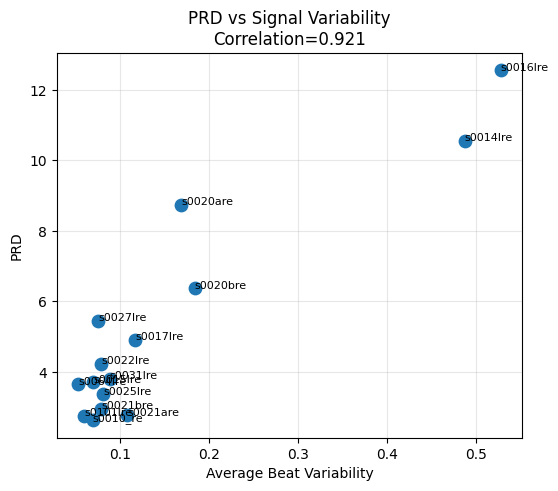

In [79]:
# ============================================
# PRD vs Signal Variability
# ============================================

plt.figure(

figsize=(6,5)

)



plt.scatter(

corr_df["Variability"],

corr_df["PRD"],

s=80

)



for i,row in corr_df.iterrows():

    plt.text(

        row["Variability"],

        row["PRD"],

        row["Record"],

        fontsize=8

    )



corr=corr_df["Variability"].corr(

    corr_df["PRD"]

)



plt.title(

f"PRD vs Signal Variability\nCorrelation={corr:.3f}"

)



plt.xlabel(

"Average Beat Variability"

)



plt.ylabel(

"PRD"

)



plt.grid(

alpha=.3

)



plt.show()